# Simulation Log Plots

This notebook compares **selfish** vs **prosocial** runs if both CSVs exist. It also works with a single run (`simulation_log.csv`).

**This does not modify the existing `result_analysis.ipynb`.**

In [7]:
!pip install pandas matplotlib
import os
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = os.path.join("..", "data", "metrics")

candidate_files = [
    "simulation_log_selfish.csv",
    "simulation_log_prosocial.csv",
    "simulation_log.csv",
]

paths = [os.path.join(DATA_DIR, f) for f in candidate_files]
existing_paths = [p for p in paths if os.path.exists(p)]

if not existing_paths:
    raise FileNotFoundError(
        "No simulation logs found. Expected one of: "
        + ", ".join(candidate_files)
        + f" in {DATA_DIR}"
    )

runs = []
for path in existing_paths:
    df = pd.read_csv(path)
    label = os.path.splitext(os.path.basename(path))[0].replace("simulation_log_", "")
    label = label.replace("simulation_log", "baseline")
    runs.append((label, df))

print("Loaded logs:")
for label, df in runs:
    print(f"- {label}: {len(df)} rows")

Loaded logs:
- selfish: 6 rows
- baseline: 2 rows


Could not find platform independent libraries <prefix>

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
summary_cols = ["tick", "intersection_delay_s", "throughput_vehicles", "collisions", "mean_speed_ms"]

for label, df in runs:
    print("\n" + "=" * 60)
    print(f"Summary: {label}")
    print("=" * 60)
    available_cols = [c for c in summary_cols if c in df.columns]
    display(df[available_cols].describe())


Summary: selfish


,tick,intersection_delay_s,throughput_vehicles,collisions,mean_speed_ms
count,6.000000,6.0,6.0,6.0,6.000000
mean,2.500000,0.0,0.0,0.0,4.983100
std,1.870829,0.0,0.0,0.0,3.260504
min,0.000000,0.0,0.0,0.0,0.000000
25%,1.250000,0.0,0.0,0.0,3.052475
50%,2.500000,0.0,0.0,0.0,5.691450
75%,3.750000,0.0,0.0,0.0,7.163050
max,5.000000,0.0,0.0,0.0,8.689300



Summary: baseline


,tick,intersection_delay_s,throughput_vehicles,collisions,mean_speed_ms
count,2.000000,2.0,2.0,2.0,2.000000
mean,0.500000,0.0,0.0,0.0,1.250000
std,0.707107,0.0,0.0,0.0,1.767767
min,0.000000,0.0,0.0,0.0,0.000000
25%,0.250000,0.0,0.0,0.0,0.625000
50%,0.500000,0.0,0.0,0.0,1.250000
75%,0.750000,0.0,0.0,0.0,1.875000
max,1.000000,0.0,0.0,0.0,2.500000


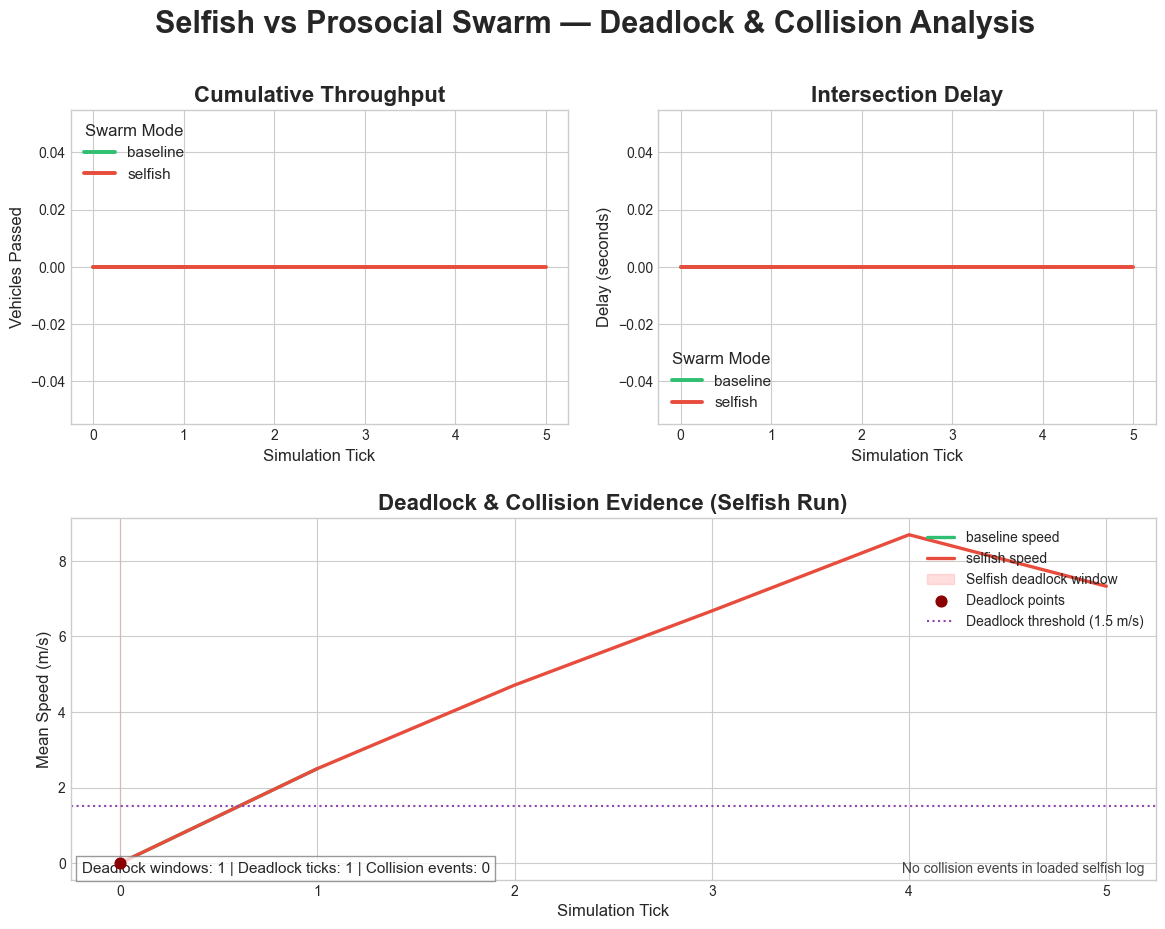

Saved figure to: C:\Users\aDMIN\OneDrive\Documents\GitHub\Autonomous-swarms\notebooks\figures\deadlock_collision_evidence.png


In [10]:
from pathlib import Path
import numpy as np

# Build a quick lookup from loaded runs in Cell 2.
run_map = {label.lower(): df.copy() for label, df in runs}

selfish_key = next((k for k in run_map if "selfish" in k), None)
if selfish_key is None:
    raise ValueError("A selfish run is required (expected a label containing 'selfish').")

comparison_key = next((k for k in run_map if k != selfish_key), None)
if comparison_key is None:
    raise ValueError("Need at least one non-selfish run to compare against.")

selfish = run_map[selfish_key].sort_values("tick").reset_index(drop=True)
comparison = run_map[comparison_key].sort_values("tick").reset_index(drop=True)

required_cols = ["tick", "throughput_vehicles", "intersection_delay_s", "mean_speed_ms", "collisions"]
for col in required_cols:
    if col not in selfish.columns or col not in comparison.columns:
        raise KeyError(f"Missing required column '{col}' in one or both runs.")

# Deadlock detection: speed below threshold.
deadlock_threshold = 1.5
min_consecutive = 1  # Keep sensitive for short test logs.
is_deadlock = selfish["mean_speed_ms"] <= deadlock_threshold

deadlock_segments = []
start = None
for i, flag in enumerate(is_deadlock):
    if flag and start is None:
        start = i
    if not flag and start is not None:
        if i - start >= min_consecutive:
            deadlock_segments.append((start, i - 1))
        start = None
if start is not None and len(is_deadlock) - start >= min_consecutive:
    deadlock_segments.append((start, len(is_deadlock) - 1))

deadlock_points = selfish.loc[is_deadlock, ["tick", "mean_speed_ms"]]

# Collision events: supports either event-per-row or cumulative counters.
collision_series = selfish["collisions"].fillna(0)
collision_delta = collision_series.diff().fillna(collision_series)
collision_events = selfish.loc[(collision_series > 0) & (collision_delta > 0), "tick"]
if collision_events.empty:
    collision_events = selfish.loc[collision_series > 0, "tick"]

plt.style.use("seaborn-v0_8-whitegrid")
fig = plt.figure(figsize=(14, 10))
grid = fig.add_gridspec(2, 2, height_ratios=[1, 1.15], hspace=0.28, wspace=0.18)

ax1 = fig.add_subplot(grid[0, 0])
ax2 = fig.add_subplot(grid[0, 1])
ax3 = fig.add_subplot(grid[1, :])

# Panel 1: cumulative throughput
ax1.plot(comparison["tick"], comparison["throughput_vehicles"], color="#2fbf71", linewidth=2.8, label=comparison_key)
ax1.plot(selfish["tick"], selfish["throughput_vehicles"], color="#e74c3c", linewidth=2.8, label=selfish_key)
ax1.set_title("Cumulative Throughput", fontsize=16, fontweight="bold")
ax1.set_xlabel("Simulation Tick", fontsize=12)
ax1.set_ylabel("Vehicles Passed", fontsize=12)
ax1.legend(title="Swarm Mode", loc="upper left", fontsize=11, title_fontsize=12)

# Panel 2: intersection delay
ax2.plot(comparison["tick"], comparison["intersection_delay_s"], color="#2fbf71", linewidth=2.8, label=comparison_key)
ax2.plot(selfish["tick"], selfish["intersection_delay_s"], color="#e74c3c", linewidth=2.8, label=selfish_key)
ax2.set_title("Intersection Delay", fontsize=16, fontweight="bold")
ax2.set_xlabel("Simulation Tick", fontsize=12)
ax2.set_ylabel("Delay (seconds)", fontsize=12)
ax2.legend(title="Swarm Mode", loc="lower left", fontsize=11, title_fontsize=12)

# Panel 3: deadlock + collisions evidence
ax3.plot(comparison["tick"], comparison["mean_speed_ms"], color="#2fbf71", linewidth=2.4, label=f"{comparison_key} speed")
ax3.plot(selfish["tick"], selfish["mean_speed_ms"], color="#e74c3c", linewidth=2.4, label=f"{selfish_key} speed")

for idx, (start_i, end_i) in enumerate(deadlock_segments):
    start_tick = selfish.loc[start_i, "tick"]
    end_tick = selfish.loc[end_i, "tick"]
    ax3.axvspan(
        start_tick,
        end_tick,
        color="#ff6b6b",
        alpha=0.22,
        label="Selfish deadlock window" if idx == 0 else None,
    )

if not deadlock_points.empty:
    ax3.scatter(
        deadlock_points["tick"],
        deadlock_points["mean_speed_ms"],
        color="#8b0000",
        marker="o",
        s=60,
        zorder=6,
        label="Deadlock points",
    )

for idx, tick in enumerate(collision_events):
    ax3.axvline(
        x=tick,
        color="black",
        linestyle="--",
        linewidth=1.2,
        alpha=0.85,
        label="Collision event" if idx == 0 else None,
    )

# Deadlock threshold guide line.
ax3.axhline(
    deadlock_threshold,
    color="#8e44ad",
    linestyle=":",
    linewidth=1.5,
    label=f"Deadlock threshold ({deadlock_threshold:.1f} m/s)",
)

deadlock_ticks = int(sum((end_i - start_i + 1) for start_i, end_i in deadlock_segments))
ax3.set_title("Deadlock & Collision Evidence (Selfish Run)", fontsize=16, fontweight="bold")
ax3.set_xlabel("Simulation Tick", fontsize=12)
ax3.set_ylabel("Mean Speed (m/s)", fontsize=12)
ax3.legend(loc="upper right", fontsize=10)

summary = (
    f"Deadlock windows: {len(deadlock_segments)} | "
    f"Deadlock ticks: {deadlock_ticks} | "
    f"Collision events: {len(collision_events)}"
)
ax3.text(
    0.01,
    0.02,
    summary,
    transform=ax3.transAxes,
    fontsize=11,
    bbox={"facecolor": "white", "alpha": 0.75, "edgecolor": "#777777"},
)

if len(collision_events) == 0:
    ax3.text(
        0.99,
        0.02,
        "No collision events in loaded selfish log",
        transform=ax3.transAxes,
        ha="right",
        fontsize=10,
        color="#444444",
    )

fig.suptitle("Selfish vs Prosocial Swarm — Deadlock & Collision Analysis", fontsize=22, fontweight="bold", y=0.98)

out_path = Path("figures") / "deadlock_collision_evidence.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {out_path.resolve()}")